# A single-band approximation for La$_{2}$CuO$_{4}$: Post-processing and Analysis

In the previous tutorial, you solved an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. We will now learn how to analyze and post-process the results we obtained in the [previous tutorial](). In this tutorial, you will learn how to:

- Analytically continue Matsubara Green's functions and self-energies
- Post-process and interpret spectral functions and self-energies

### 🧪 Exercise 0: Load the converged DMFT from HDF5

In [1]:
from h5 import HDFArchive
from triqs.gf import MeshImFreq, BlockGf

with HDFArchive('ref_data/lco-beta=10.0-U=3.6.h5') as ar:
    last_iter = str(len(ar)-1)
    mu = ar[last_iter]['mu']
    Sigma_iw = ar[last_iter]['Sigma_iw']
    G_iw = ar[last_iter]['G_iw']

### 🧪 Exercise 1: Estimate Z from the Matsubara self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega_{n}}\text{Im}\Sigma(i\omega_{n}) |_{\omega_{n}\rightarrow 0})^{-1}.$$

We can estimate this quantity a couple of different ways. The simplest is to just look at the first Matsubara point,

$$ Z \sim \Big (1 - \frac{\mathrm{Im}\Sigma(i\omega_{0})}{\omega_{0}} \Big )^{-1},$$
where $\omega_{0} = \frac{\pi}{\beta}$.

Z= 0.16676528809176008


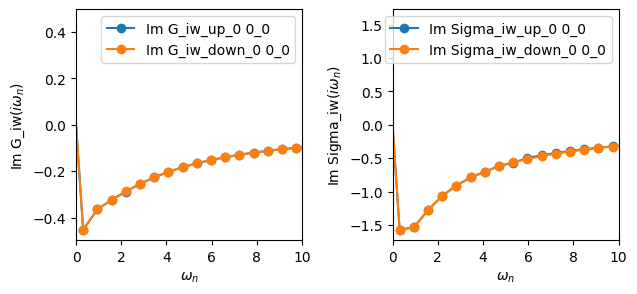

In [2]:
from triqs.plot.mpl_interface import oplot, plt
import numpy as np

beta = 10.0

Z = 1/(1 - Sigma_iw['up_0'][0,0](0).imag*beta/np.pi)
print(f'Z= {Z}')

fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(G_iw.imag, 'o-')
ax[1].oplot(Sigma_iw.imag, 'o-')
ax[0].set_xlim(0,10)
plt.subplots_adjust(wspace=0.4)
plt.show()

## 🌀 Analytic continuation: from Matsubara to real frequencies

In this section, we will learn how to **analytically continue** our results from Matsubara (imaginary) frequencies onto the real-frequency axis, so that we may plot spectral functions. Because analytic continuation is an ill-posed problem, it is notoriously unstable, and the method itself remains an active area of research. However, there are two common analytic continuation techniques: Padé analytic continuation and the maximum entropy (MaxEnt) method. In this section, we will use Padé analytic contintuation since it is simpler. There is an additional tutorial using the MaxEnt method to continue the data.

### ❓The problem
We assume the Matsubra Green's function $G(i\omega_{n})$ corresponds to a dynamic correlation function $G(\omega)$ where $\omega_{n}$ is the Matsubara frequency and $\omega$ is the real frequency. The function $G(z)$ is analytic in the whole upper complex plane of $z$ excluding the real axis, the retarded Green function can be obtained by analytic contintuation $$G(\omega) = G(i\omega_{n}\rightarrow \omega + i0^{+})$$. The spectral function $A(\omega)$ is determined by taking the imaginary part of $G(\omega + i0^{+})$ by the formula

$$ A(\omega) = -\frac{1}{\pi}\mathrm{Im}G(\omega + i0^{+})$$

### 📐 Padé method
Padé analytic continuation is based on the assumption that the Matsubara Green function can be approximated by a rational function of degree $r$

$$ G(z) = \frac{\sum_{i=0}^{r-1} p_{i}z^{i}}{\sum_{j=0}^{r-1}q_{j}z^{j} + z^{r}}, $$
where $p_{i}$ and $q_{j}$ are complex. The coefficients can be determined by solving $2r$ linear equatiions from $2r$ arbitrary but different input points ${i\omega_{n}, G(i\omega_{n})}$. Once the coefficients are determined, we replace $z$ with $\omega + i0^{+}$ to obtain the retarded correlation function.

### 🧪 Exercise 2: Analytically continue the Matsubara Green's function

In this exercise, we will analytically continue the Matsubara Green's function onto the real frequency axis.

#### 🧩 Your task
1. set up a ``BlockGf`` with a real frequency mesh ``MeshReFreq``.
2. For each block in the Matsubara Green's function, use the ``set_from_pade`` method to obtain the real frequency Green's function for each block.
4. Plot the resulting spectral function using the formula $A(\omega) = -\frac{1}{\pi}\text{Im}G(\omega + i0^{+})$.

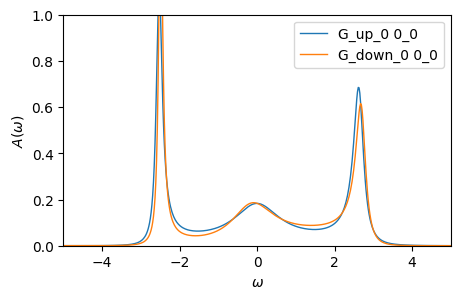

In [3]:
from triqs.gf import MeshReFreq
import numpy as np

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in G_iw ]

## setup real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in G_w: 
    g.set_from_pade(G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(figsize=(5,3))
ax.oplot(-1/np.pi*G_w.imag, lw=1)
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
plt.show()

> ⚠️ **Warning**: The Pade method can be sensitive to the choice of ``n_points``, which correpsonds to the amount of Matsubara data you allow the algorithm to see. Try changing this parameter to see how the resulting spectral function changes.

### 🌀 MaxEnt for a Green's function
Let's compare our Padé results to results obtained using the maximum entropy method. Within the TRIQS ecosystem, we have a maximum entropy suite (TRIQS/maxent) which allows one to analytically continue TRIQS Green's function objects to obtain real-frequency spectra. Here, we have abstracted away much of the boiler plate code and provide you a free function ``Aw_from_maxent`` inside of the ``utils.maxent`` module. Let's try loading this module:

```python
from utils.maxent import Aw_from_maxent
```
and using the function ``Aw_from_maxent``, which takes as an argument a Matsubara Green's function.

> 💡 **Tip**: Don't forget about the ``?function_name`` functionality of Jupyter notebooks which allows you to check the API of a function within the notebook itself.

In [4]:
from utils.maxent import Aw_from_maxent

mesh, Aw = Aw_from_maxent(G_iw, omega_min=-10, 
                                omega_max= 10, 
                                alpha_min=1e-6, 
                                alpha_max=1e2, 
                                n_alpha_points=50, 
                                n_omega_points=200, 
                                error=0.02)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-10 09:46:47.906566
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.0006747819503867674
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.12895743e+04, n_iter=       5 
alpha[ 1] =   1.03477981e+05, chi2 =   9.19236048e+03, n_iter=       4 
alpha[ 2] =   7.10530361e+04, chi2 =   7.03532044e+03, n_iter=       4 
alpha[ 3] =   4.87884852e+04, chi2 =   5.11242698e+03, n_iter=       4 


Starting serial run at: 2025-08-10 09:46:47.752551


alpha[ 4] =   3.35005570e+04, chi2 =   3.62352310e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   2.58864234e+03, n_iter=       4 
alpha[ 6] =   1.57950649e+04, chi2 =   1.90504813e+03, n_iter=       4 
alpha[ 7] =   1.08456631e+04, chi2 =   1.44567354e+03, n_iter=       4 
alpha[ 8] =   7.44716204e+03, chi2 =   1.11468134e+03, n_iter=       4 
alpha[ 9] =   5.11358521e+03, chi2 =   8.57819717e+02, n_iter=       4 
alpha[10] =   3.51123738e+03, chi2 =   6.51512303e+02, n_iter=       4 
alpha[11] =   2.41098709e+03, chi2 =   4.87494176e+02, n_iter=       4 
alpha[12] =   1.65550150e+03, chi2 =   3.61182017e+02, n_iter=       4 
alpha[13] =   1.13674819e+03, chi2 =   2.66523966e+02, n_iter=       4 
alpha[14] =   7.80546834e+02, chi2 =   1.96023952e+02, n_iter=       4 
alpha[15] =   5.35961582e+02, chi2 =   1.42756142e+02, n_iter=       4 
alpha[16] =   3.68017401e+02, chi2 =   1.01817892e+02, n_iter=       4 
alpha[17] =   2.52698724e+02, chi2 =   7.03833721e+01, n_iter=  

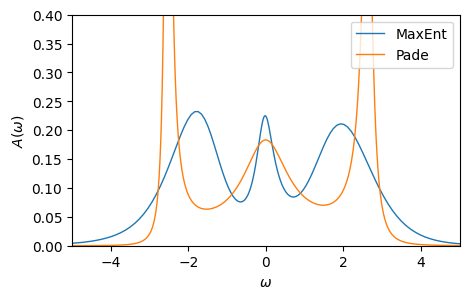

In [5]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 0.4)
plt.show()

### 🧪 Exercise 3: Understanding your spectral function

Let's take a closer look out the spectral functions that we just obtained. Specifically, let's see if it reproduces the features that we expect, which are spectral weight transfer into the upper and lower Hubbard bands around $\pm U/2$ as well as the width of the quasiparticle peak which goes as $\sim Z \Gamma$, where $\Gamma = -\mathrm{Im}\Sigma(0)$.

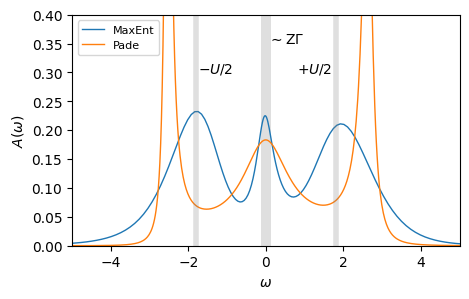

In [6]:
# plot from above
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 0.4)
ax.legend(loc='upper left', fontsize = 8)

# Step 1: add lines where the upper and lower Hubbard bands should be
U = 3.6

# We expect upper and lower Hubbard bands at +/- U/2
ax.axvline(+U/2, color='grey', lw=4, alpha=0.25); ax.axvline(-U/2, color='grey', lw=4, alpha=0.25)
ax.text(-1.75, 0.3, r'$-U/2$'); ax.text(0.8, 0.3, r'$+U/2$')

# Step 2: add a column that is proportional to the width of the quasiparticle peak

# We expect the width of the peak to be Z*ImΣ(0)
Gamma = -Sigma_iw['up_0'][0,0](0).imag
ax.axvspan(-0.5*Z*Gamma, 0.5*Z*Gamma, color='grey', lw=0, alpha=0.25); ax.text(0.05, 0.35, r'$\sim$Z$\Gamma$')

plt.show()

### 🧪 Exercise 4: Analytically continue the Matsubara self-energy

In this exercise, we will analytically continue the Matsubara self-energy onto the real-frequency axis. Due to implementation details, you can directly use the same Python code to analytically continue a self-energy in the same way as a Green's function in TRIQS. 

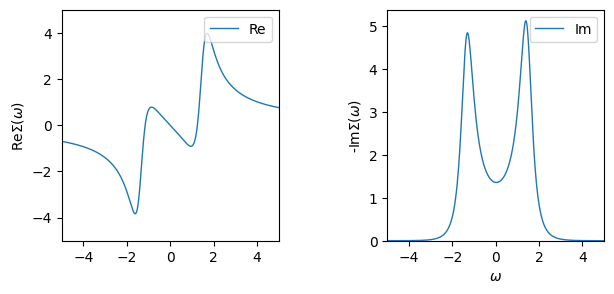

In [7]:
n_w = 1000
window = (-10, 10)

mesh = MeshReFreq(window, n_w)
# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w_pade = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in Sigma_w_pade: g.set_from_pade(Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Re')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Im')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-5,5); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🌀 MaxEnt for a Self-energy
Again, let's compare our Padé results to results obtained using the maximum entropy method. This time you will use the free function ``Sigma_w_from_maxent`` inside of the ``utils.maxent`` module. Let's try loading this module:

```python
from utils.maxent import Sigma_w_from_maxent
```
and using the function ``Sigma_w_from_maxent``, which takes as an argument a Matsubara self-energy.

In [8]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, error=0.02)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-10 09:46:52.753114
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.0010947817609085026
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.36069998e+04, n_iter=       5 
alpha[ 1] =   1.03477981e+05, chi2 =   1.14757941e+04, n_iter=       4 
alpha[ 2] =   7.10530361e+04, chi2 =   9.15524396e+03, n_iter=       4 
alpha[ 3] =   4.87884852e+04, chi2 =   6.90782155e+03, n_iter=       4 
alpha[ 4] =   3.35005570e+04, chi2 =   4.98415427e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   3.50841082e+03, n_iter=       4 

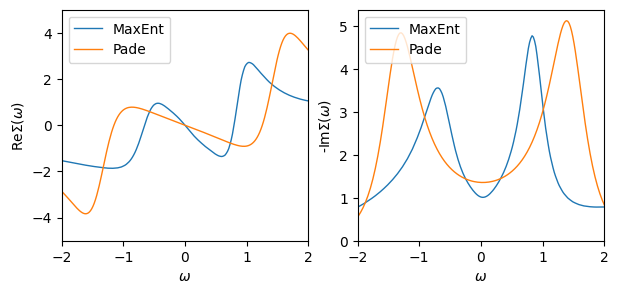

In [9]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
# maxent
ax[0].oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1, label='MaxEnt')
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1, label='MaxEnt')
# pade
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Pade')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Pade')
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-2,2); ax[1].set_ylim(0, ); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

### 🧪 Exercise 5: Estimate Z and the scattering rate from the self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega}\text{Re}\Sigma(\omega) |_{\omega\rightarrow0})^{-1}.$$
The scattering rate $\Gamma$ is proportional to $-\mathrm{Im}\Sigma(\omega=0)$. For $Z$, you can fit a linear line to the low-frequency data in the real part of spectrum and use the slope of the line to estimate the derivate.  For the scattering rate, you can fit a polynomial to the low-frequency data in the imaginary part of the self-energy and estimate $-\text{Im}\Sigma(0)$ from this fit.

In [10]:
x = np.linspace(-0.2, 0.2,10)
y = [Sigma_w['up_0'][0,0](xx).real for xx in x]
dSdw = np.polyfit(x,y,1)[0]
Z = 1/(1 - dSdw)
print(f'     Z  =  {Z}')
print(f'-ImΣ(0) =  {-Sigma_w['up_0'][0,0](0.0).imag}')

     Z  =  0.2511944563800386
-ImΣ(0) =  1.0172608836872563


## 📊 Plotting your results

### 🧪 Exercise 6: Plot the momentum-resolved spectral function along the high-symmetry path in the Brillouin zone
Let's plot the spectral function along a high-symmetry path in the Brillouin zone. This means we will compute

$$ A(k,\omega) = -\frac{1}{\pi} \mathrm{Im} G_{\mathrm{latt}}(k, \omega), $$
where $G_{\mathrm{latt}}$ is the lattice Green's function defined previously. First, we will prepare a list of $k$ points along a high-symmetry direction in the first Brillouin zone of La$_{2}$CuO$_{4}$. Using our converged chemical potential ($\mu$) and self-energy in real frequencies ($\Sigma(\omega)$), we can compute $A(k,\omega)$ with the utility function ``momentum_resolved_spectral_function``.

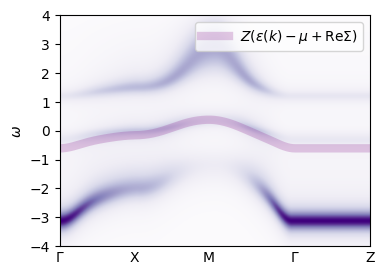

In [11]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path
from utils.mpl_interface import *

# create high-symmetry path
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments)


# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("./data/mlwf/lco", 
                                                            "NonPolarized", [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)])

# compute the disperion along the high-symmetry directions
e_k = obe.H[0].eigenvalues(k_points).real

# compute the spectral function
A_kw = momentum_resolved_spectral_function(e_k, mu, Sigma_w['up_0'], broadening=0.1)

fig, ax = plt.subplots(figsize=(4,3))

# plot the spectral function
ax.plot_spectral_function(A_kw, k_lin, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0)

# plot the QP dispersion
Z = 0.25119445637993476
ax.plot(k_lin, Z*(e_k[:,0] - mu + Sigma_w['up_0'][0,0](0).real), '-', lw=6, color='purple', alpha=0.2, label=r'$Z(\varepsilon(k)-\mu + \mathrm{Re}\Sigma)$')

ax.legend()
ax.set_ylim(-4,4)
plt.show()

### 🧪 Exercise 7: Describe your results
In a few words, describe your spectral function results $A(k, \omega)$. Compare the interacting spectrum to the non-interacting. Can you connect any of these changes to features in the self-energy?

From the momentum-resolved spectral function shown above, we see two distinct features: upper and lower Hubbard bands forming around $\pm U/2$ and a signficant band renormalization due to small quasiparticle renormalization factor, $Z$.